# EDA Cartola — Limpieza, normalización (UBER) y visualizaciones

Este notebook parte desde **cero**: carga el CSV, hace limpieza mínima, crea columnas útiles para análisis (gastos/abonos), normaliza **solo UBER**, y genera gráficos para tendencias y distribución.

**Entrada:** `movimientos_cartola_2025-12_a_2026-01.csv`

> Tip: Si tu archivo tiene otro nombre, cambia `CSV_PATH` en la primera celda.


## 0) Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mostrar números con separador de miles en prints
pd.options.display.float_format = '{:,.0f}'.format


## 1) Cargar CSV (y validar columnas)

In [2]:
# Cambia esto si tu archivo está en otra ruta/nombre
CSV_PATH = "movimientos_cartola_2025-12_a_2026-01.csv"

df = pd.read_csv(CSV_PATH)

# Tipos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["monto_clp"] = pd.to_numeric(df["monto_clp"], errors="coerce")

# Validación básica
print("Filas:", len(df))
print("Columnas:", list(df.columns))
df.head()


Filas: 100
Columnas: ['fecha', 'descripcion', 'canal', 'monto_clp', 'tipo', 'monto_abs_clp']


,fecha,descripcion,canal,monto_clp,tipo,monto_abs_clp
0,2025-12-25,PAGO ESQUINACARNE,Débito nacional,-40520,cargo,40520
1,2025-12-25,ABONO CONVENIO BANCO DE CREDITO E I,Bancoestado,1853097,abono,1853097
2,2025-12-27,TEF A GABRIELA CATHERINA RIVERA CAS,App,-500000,cargo,500000
3,2025-12-27,PAGO UNIV AUTONOMA DE,Débito nacional,-101574,cargo,101574
4,2025-12-27,PAGO MELIMAS,Débito nacional,-6990,cargo,6990


## 2) Limpieza mínima + columnas para EDA

In [3]:
# Normaliza texto (opcional pero útil)
df["descripcion"] = df["descripcion"].astype(str).str.strip()
df["canal"] = df["canal"].astype(str).str.strip()

# Columnas útiles
df["tipo_calc"] = np.where(df["monto_clp"] > 0, "abono", "cargo")
df["gasto_clp"] = np.where(df["monto_clp"] < 0, -df["monto_clp"], 0)   # gasto positivo
df["abono_clp"] = np.where(df["monto_clp"] > 0, df["monto_clp"], 0)    # abono positivo

# Revisar nulos críticos
print("Nulos fecha:", df["fecha"].isna().sum())
print("Nulos monto_clp:", df["monto_clp"].isna().sum())

df.sort_values("fecha").head(10)


Nulos fecha: 0
Nulos monto_clp: 0


,fecha,descripcion,canal,monto_clp,tipo,monto_abs_clp,tipo_calc,gasto_clp,abono_clp
0,2025-12-25,PAGO ESQUINACARNE,Débito nacional,-40520,cargo,40520,cargo,40520,0
1,2025-12-25,ABONO CONVENIO BANCO DE CREDITO E I,Bancoestado,1853097,abono,1853097,abono,0,1853097
2,2025-12-27,TEF A GABRIELA CATHERINA RIVERA CAS,App,-500000,cargo,500000,cargo,500000,0
3,2025-12-27,PAGO UNIV AUTONOMA DE,Débito nacional,-101574,cargo,101574,cargo,101574,0
4,2025-12-27,PAGO MELIMAS,Débito nacional,-6990,cargo,6990,cargo,6990,0
5,2025-12-27,PAGO UBER TRIP,Débito nacional,-4017,cargo,4017,cargo,4017,0
12,2025-12-28,COMPRAQUI WEB ENTEL RECARGAS,Pagos móviles,-1000,cargo,1000,cargo,1000,0
11,2025-12-28,PAGO UBER TRIP,Débito nacional,-1715,cargo,1715,cargo,1715,0
9,2025-12-28,PAGO ANDREALETICIA,Débito nacional,-12500,cargo,12500,cargo,12500,0
10,2025-12-28,PAGO BOTILLERIA MAI,Débito nacional,-9000,cargo,9000,cargo,9000,0


## 3) Normalización mínima: solo UBER (PAGO UBER TRIP / PAGO UBER → UBER)
Se crea `descripcion_norm` y se usa en los agrupamientos.

In [4]:
df["descripcion_norm"] = df["descripcion"].replace({
    "PAGO UBER TRIP": "UBER",
    "PAGO UBER": "UBER",
})

# Alternativa robusta si aparecen variantes (descomenta si lo necesitas)
# df["descripcion_norm"] = np.where(df["descripcion"].str.contains(r"\bUBER\b", na=False), "UBER", df["descripcion_norm"])

df[["descripcion", "descripcion_norm"]].drop_duplicates().sort_values("descripcion").head(30)


,descripcion,descripcion_norm
1,ABONO CONVENIO BANCO DE CREDITO E I,ABONO CONVENIO BANCO DE CREDITO E I
72,COMISION GIRO CAJERO AUTOMATICO,COMISION GIRO CAJERO AUTOMATICO
22,COMISION TEF TERCEROS A OTROS BANCO,COMISION TEF TERCEROS A OTROS BANCO
46,COMISION TRANSACCION INTERNACIONAL,COMISION TRANSACCION INTERNACIONAL
12,COMPRAQUI WEB ENTEL RECARGAS,COMPRAQUI WEB ENTEL RECARGAS
54,COMPRAQUI WEB MOVISTAR RECARGAS,COMPRAQUI WEB MOVISTAR RECARGAS
58,COMPRAQUI WEB WOM RECARGAS,COMPRAQUI WEB WOM RECARGAS
44,GIRO CAJA VECINA,GIRO CAJA VECINA
67,GIRO CAJA VECINA 20:53,GIRO CAJA VECINA 20:53
90,GIRO CAJA VECINA 23:26,GIRO CAJA VECINA 23:26


## 4) Resúmenes rápidos

In [5]:
total_gastos = df["gasto_clp"].sum()
total_abonos = df["abono_clp"].sum()
neto = total_abonos - total_gastos

print(f"Total gastos: ${total_gastos:,.0f} CLP")
print(f"Total abonos: ${total_abonos:,.0f} CLP")
print(f"Neto (abonos - gastos): ${neto:,.0f} CLP")


Total gastos: $2,012,702 CLP
Total abonos: $2,065,575 CLP
Neto (abonos - gastos): $52,873 CLP


## 5) Descripciones repetidas (>=2) — para priorizar análisis

In [6]:
repetidas = df["descripcion_norm"].value_counts().reset_index()
repetidas.columns = ["descripcion_norm", "n_movimientos"]
repetidas = repetidas[repetidas["n_movimientos"] >= 2].sort_values("n_movimientos", ascending=False)

repetidas.head(30)


,descripcion_norm,n_movimientos
0,UBER,10
1,COMISION TEF TERCEROS A OTROS BANCO,9
2,PAGO BOTILLERIA MAI,7
3,PAGO EL BAUL DE LA ABU,7
4,TEF A ENRIQUE IGNACIO SUAREZ PERALT,6
5,PAGO ESQUINACARNE,5
6,TEF A GABRIELA CATHERINA RIVERA CAS,5
7,COMPRAQUI WEB ENTEL RECARGAS,5
8,PAGO UNIMARC VALLENAR,4
9,COMPRAQUI WEB WOM RECARGAS,3


## 6) Top gastos por descripción normalizada (tabla)

In [7]:
TOP_N = 20

gastos_por_desc = (
    df[df["gasto_clp"] > 0]
      .groupby("descripcion_norm", as_index=False)["gasto_clp"]
      .sum()
      .sort_values("gasto_clp", ascending=False)
      .reset_index(drop=True)
)

gastos_por_desc.head(TOP_N)


,descripcion_norm,gasto_clp
0,TEF A GABRIELA CATHERINA RIVERA CAS,620000
1,TEF A ENRIQUE IGNACIO SUAREZ PERALT,222000
2,TEF A LAURA DEL ROSARIO PERALTA ARA,180008
3,PAGO UNIMARC VALLENAR,126045
4,PAGO ESTUDIOS EUROPEOS,112122
5,PAGO ESQUINACARNE,109900
6,PAGO UNIV AUTONOMA DE,101574
7,GIRO REDBANC 20:41 2026-01-10,100000
8,PAGO EL BAUL DE LA ABU,35090
9,PAGO BOTILLERIA MAI,33800


## 7) Gráfico — Top gastos por descripción (barras horizontales)

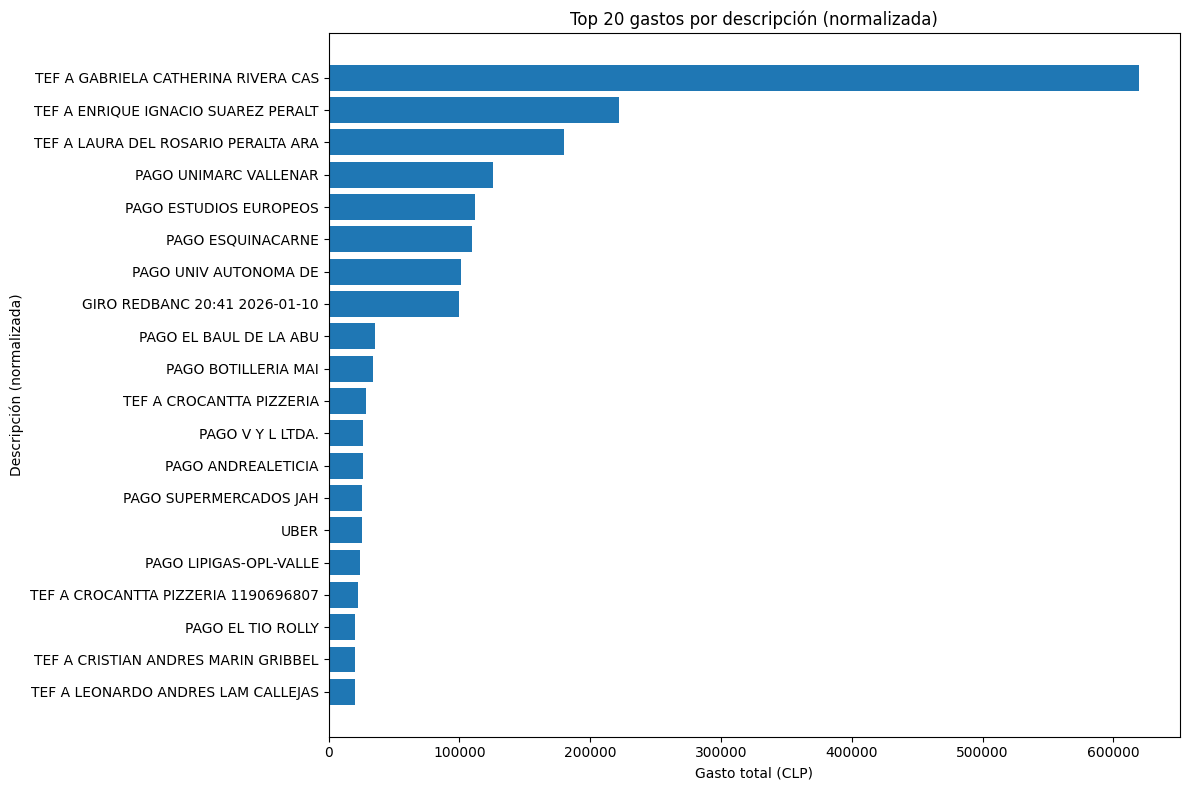

In [8]:
TOP_N = 20
plot_df = gastos_por_desc.head(TOP_N).sort_values("gasto_clp", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(plot_df["descripcion_norm"], plot_df["gasto_clp"])
plt.xlabel("Gasto total (CLP)")
plt.ylabel("Descripción (normalizada)")
plt.title(f"Top {TOP_N} gastos por descripción (normalizada)")
plt.tight_layout()
plt.show()


## 8) Tendencia — gasto diario + media móvil (7 días)

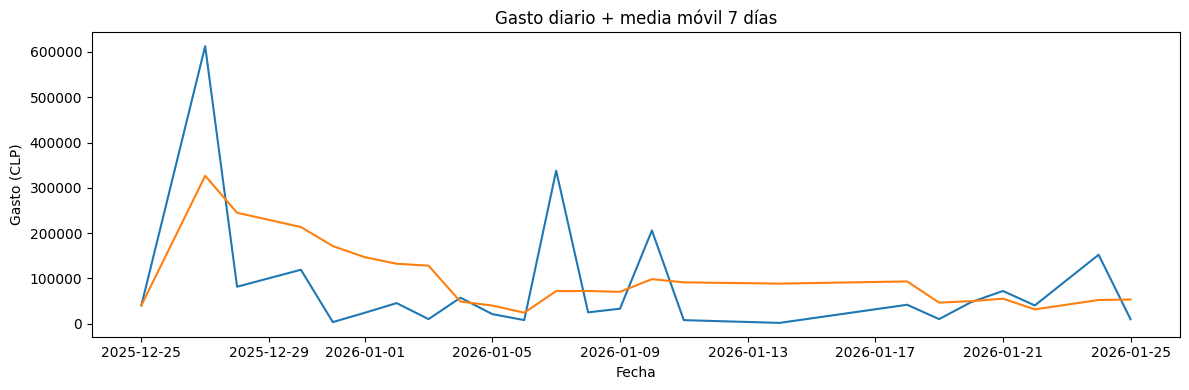

,fecha,gasto_clp,mm7
14,2026-01-10,205989,"98,488"
15,2026-01-11,8057,"91,416"
16,2026-01-14,2000,"88,659"
17,2026-01-18,42000,"93,485"
18,2026-01-19,10300,"46,697"
19,2026-01-20,47650,"49,899"
20,2026-01-21,72380,"55,482"
21,2026-01-22,40519,"31,844"
22,2026-01-24,152300,"52,450"
23,2026-01-25,10000,"53,593"


In [9]:
daily = (df[df["gasto_clp"] > 0]
         .groupby("fecha", as_index=False)["gasto_clp"]
         .sum()
         .sort_values("fecha"))

daily["mm7"] = daily["gasto_clp"].rolling(7, min_periods=1).mean()

plt.figure(figsize=(12, 4))
plt.plot(daily["fecha"], daily["gasto_clp"])
plt.plot(daily["fecha"], daily["mm7"])
plt.xlabel("Fecha")
plt.ylabel("Gasto (CLP)")
plt.title("Gasto diario + media móvil 7 días")
plt.tight_layout()
plt.show()

daily.tail(10)


## 9) Pie chart — distribución de gastos (Top N + OTROS) con $ por grupo
Nota: el pie se vuelve ilegible con demasiadas categorías; usa **TOP_N** ~ 10–15.

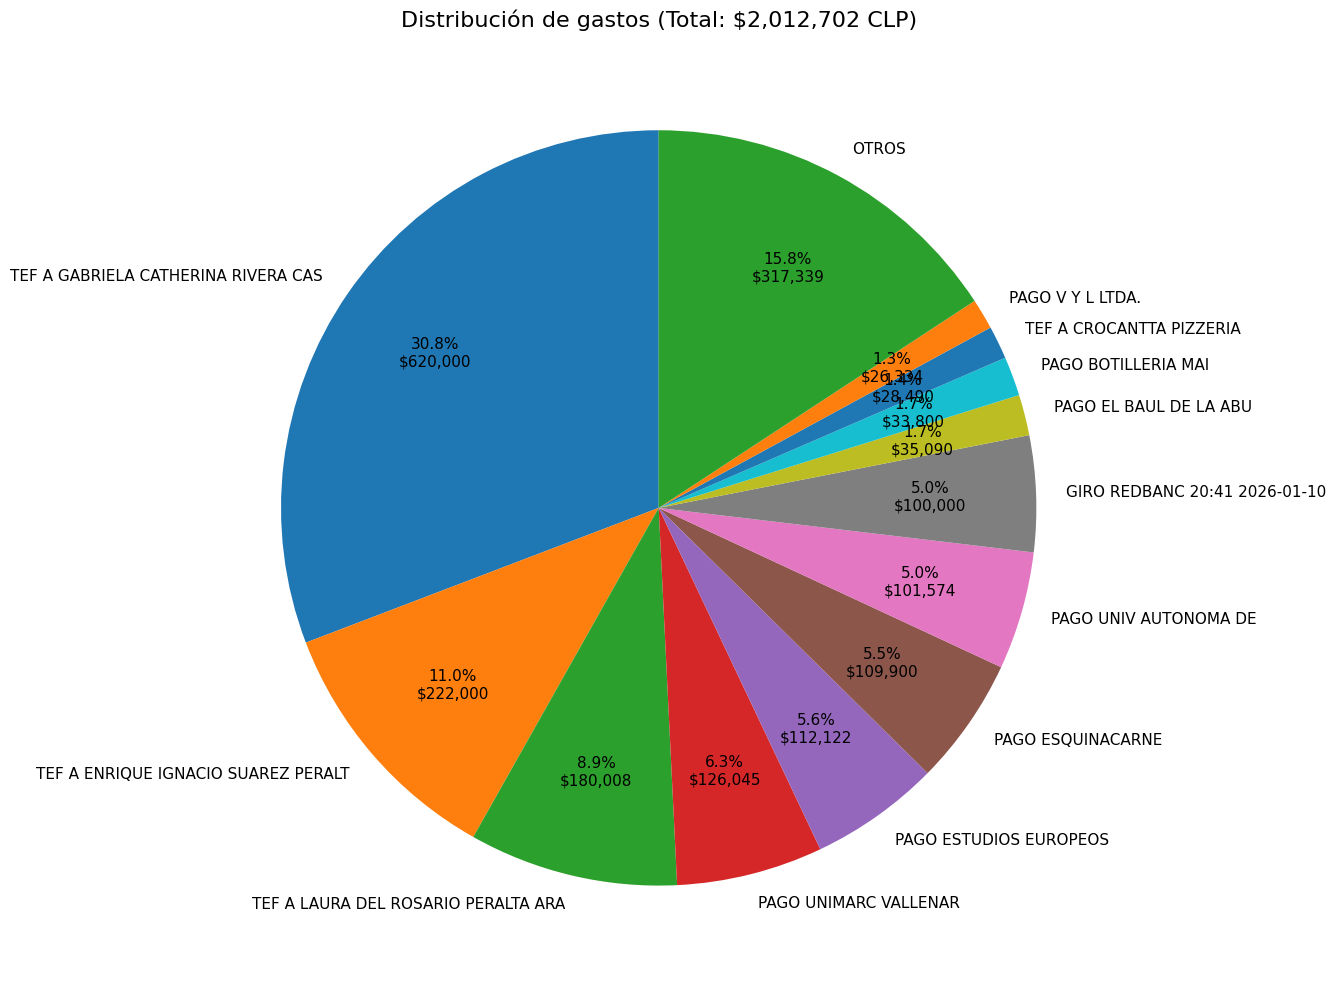

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 12

top = gastos_por_desc.copy()
topN = top.head(TOP_N).copy()
otros_total = top.iloc[TOP_N:]["gasto_clp"].sum()

if otros_total > 0:
    topN = pd.concat([topN, pd.DataFrame([{
        "descripcion_norm": "OTROS",
        "gasto_clp": otros_total
    }])], ignore_index=True)

total_gasto = top["gasto_clp"].sum()

labels = topN["descripcion_norm"].tolist()
values = topN["gasto_clp"].tolist()

def make_autopct(vals):
    total = sum(vals)
    def _autopct(pct):
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n${val:,.0f}"
    return _autopct

plt.figure(figsize=(14, 10))
plt.pie(
    values,
    labels=labels,
    autopct=make_autopct(values),
    startangle=90,
    textprops={"fontsize": 11},
    pctdistance=0.72,
    labeldistance=1.08
)
plt.title(f"Distribución de gastos (Total: ${total_gasto:,.0f} CLP)", fontsize=16)
plt.tight_layout()
plt.show()


## 10) Mapa de calor — gastos del mes completo (día del mes x día de semana)
Usa el **último mes** detectado en los datos. Puedes forzar otro mes con `MES='2026-01'`.

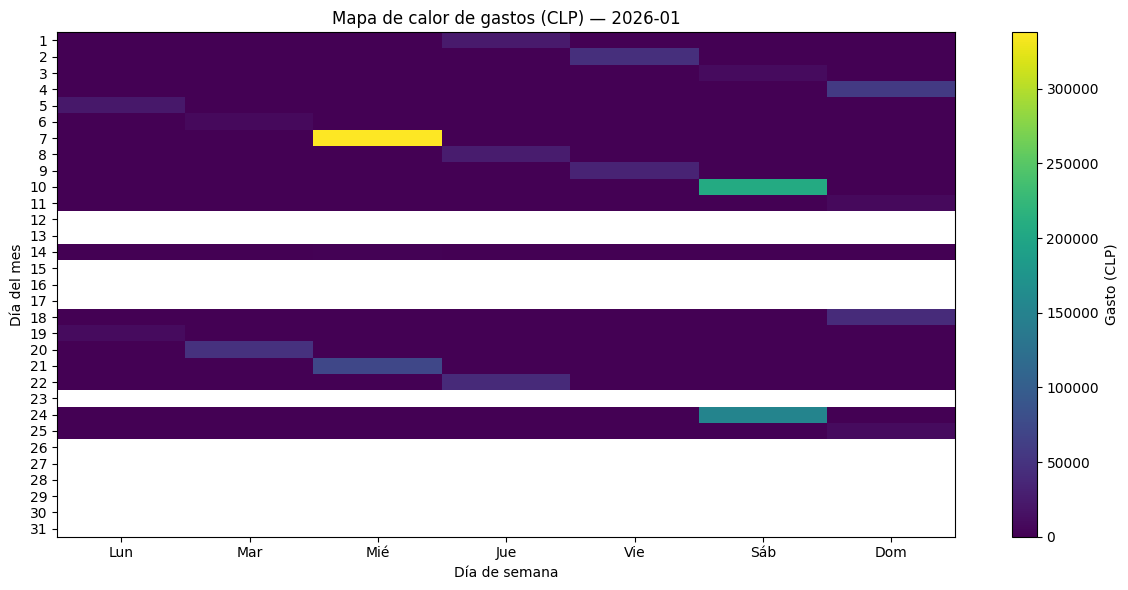

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g = df[df["gasto_clp"] > 0].copy()

# Forzar mes (opcional): MES = "2026-01"
MES = None  # ej: "2026-01"

if MES is None:
    mes = g["fecha"].dt.to_period("M").max()
else:
    mes = pd.Period(MES, freq="M")

gm = g[g["fecha"].dt.to_period("M") == mes].copy()

gm["dia_mes"] = gm["fecha"].dt.day
gm["dow"] = gm["fecha"].dt.dayofweek  # 0=Lun ... 6=Dom

heat = (gm.groupby(["dia_mes", "dow"])["gasto_clp"].sum().unstack(fill_value=0))

heat = heat.reindex(columns=range(7), fill_value=0).reindex(index=range(1, 32), fill_value=np.nan)

plt.figure(figsize=(12, 6))
plt.imshow(heat.values, aspect="auto")
plt.xticks(range(7), ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"])
plt.yticks(range(31), [str(i) for i in range(1, 32)])
plt.xlabel("Día de semana")
plt.ylabel("Día del mes")
plt.title(f"Mapa de calor de gastos (CLP) — {mes}")
cbar = plt.colorbar()
cbar.set_label("Gasto (CLP)")
plt.tight_layout()
plt.show()


## 11) Exportar dataset enriquecido (opcional)
Guarda un CSV con columnas nuevas (`gasto_clp`, `abono_clp`, `descripcion_norm`).

In [ ]:
OUT_CSV = "movimientos_enriquecido.csv"
df.to_csv(OUT_CSV, index=False, encoding="utf-8")
print("Guardado:", OUT_CSV)
